## Import

In [1]:
import pandas as pd
import numpy as np
import pickle
from moviepy.editor import VideoFileClip
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import parselmouth
from IPython.display import Audio, display
from librosa import display
import datetime
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import xgboost as xgb
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
from keras.optimizers import Adam
import joblib

## Model Training

In [4]:
# Load the preprocessed dataset
data = pd.read_csv("personality_training_data_whole_all2.csv")

# Display column names in the dataset
print("Column names in the dataset:")
print(data.shape)
print(data.columns)

Column names in the dataset:
(10000, 171)
Index(['intensity_mean', 'intensity_min', 'intensity_max', 'intensity_std_dev',
       'pitch_mean', 'pitch_min', 'pitch_max', 'pitch_std_dev', 'energy',
       'speech_rate',
       ...
       'hnr_std_dev', 'rms_mean', 'rms_min', 'rms_max', 'rms_std_dev',
       'zero_crossing_rate_mean', 'zero_crossing_rate_min',
       'zero_crossing_rate_max', 'zero_crossing_rate_std_dev', 'label'],
      dtype='object', length=171)


In [47]:
# # Downsample to minimum class size
# min_samples = data['label'].value_counts().min()
# balanced_data = pd.DataFrame()
# for label in data['label'].unique():
#     label_data = data[data['label'] == label]
#     downsampled = label_data.sample(n=min_samples, random_state=42)
#     balanced_data = pd.concat([balanced_data, downsampled])

# data = balanced_data

In [5]:
# Count the occurrences of each label
label_counts = data['label'].value_counts()

# Print the counts
print("\nLabel distribution:")
print(label_counts)


Label distribution:
label
openness             3536
agreeableness        2651
conscientiousness    2140
neuroticism          1132
extraversion          541
Name: count, dtype: int64


In [6]:
#Upsampling
from sklearn.utils import resample

# Separate each class into different DataFrames
dfs = [data[data['label'] == label] for label in data['label'].unique()]

# Find the maximum class size
max_size = max(len(df) for df in dfs)

# Upsample each class to the maximum class size
upsampled_dfs = [resample(df, replace=True, n_samples=max_size, random_state=42) for df in dfs]

# Combine the upsampled DataFrames
upsampled_data = pd.concat(upsampled_dfs)

# Shuffle the combined DataFrame
upsampled_data = upsampled_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the new class distribution
print("\nNew label distribution after upsampling:")
print(upsampled_data['label'].value_counts())


New label distribution after upsampling:
label
agreeableness        3536
extraversion         3536
openness             3536
neuroticism          3536
conscientiousness    3536
Name: count, dtype: int64


In [7]:
# from imblearn.over_sampling import SMOTE

# # Separate features and labels
# X = data.iloc[:, :-1].values  # All features
# y = data.iloc[:, -1].values  # labels

# # Encode labels
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)

# # Apply SMOTE to upsample the minority classes
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X, y_encoded)

# # Convert the resampled data back to a DataFrame
# upsampled_data_smote = pd.DataFrame(X_resampled, columns=data.columns[:-1])
# upsampled_data_smote['label'] = le.inverse_transform(y_resampled)

# # Display the new class distribution
# print("\nNew label distribution after SMOTE upsampling:")
# print(upsampled_data_smote['label'].value_counts())

In [110]:
# # Downsample to minimum class size
# min_samples = data['label'].value_counts().min()
# balanced_data = pd.DataFrame()
# for label in data['label'].unique():
#     label_data = data[data['label'] == label]
#     downsampled = label_data.sample(n=min_samples, random_state=42)
#     balanced_data = pd.concat([balanced_data, downsampled])

# # Display the new class distribution
# print("\nNew label distribution after downsampling:")
# print(balanced_data['label'].value_counts())


New label distribution after downsampling:
label
openness             541
agreeableness        541
conscientiousness    541
neuroticism          541
extraversion         541
Name: count, dtype: int64


In [8]:
# Print all columns in a vertical format
print("\n".join(list(data.columns)))

intensity_mean
intensity_min
intensity_max
intensity_std_dev
pitch_mean
pitch_min
pitch_max
pitch_std_dev
energy
speech_rate
spectral_centroid_mean
spectral_centroid_min
spectral_centroid_max
spectral_centroid_std_dev
spectral_bandwidth_mean
spectral_bandwidth_min
spectral_bandwidth_max
spectral_bandwidth_std_dev
spectral_flatness_mean
spectral_flatness_min
spectral_flatness_max
spectral_flatness_std_dev
spectral_rolloff_mean
spectral_rolloff_min
spectral_rolloff_max
spectral_rolloff_std_dev
mfcc_0_mean
mfcc_1_mean
mfcc_2_mean
mfcc_3_mean
mfcc_4_mean
mfcc_5_mean
mfcc_6_mean
mfcc_7_mean
mfcc_8_mean
mfcc_9_mean
mfcc_10_mean
mfcc_11_mean
mfcc_12_mean
mfcc_0_min
mfcc_1_min
mfcc_2_min
mfcc_3_min
mfcc_4_min
mfcc_5_min
mfcc_6_min
mfcc_7_min
mfcc_8_min
mfcc_9_min
mfcc_10_min
mfcc_11_min
mfcc_12_min
mfcc_0_max
mfcc_1_max
mfcc_2_max
mfcc_3_max
mfcc_4_max
mfcc_5_max
mfcc_6_max
mfcc_7_max
mfcc_8_max
mfcc_9_max
mfcc_10_max
mfcc_11_max
mfcc_12_max
mfcc_0_std_dev
mfcc_1_std_dev
mfcc_2_std_dev
mfcc_3_

In [9]:
# Separate features and labels
X = upsampled_data.iloc[:, :-1].values  # All features 
# X = upsampled_data.loc[:, upsampled_data.columns.str.startswith(('pitch', 'intensity'))].values # Pitch and intensity features
# X = upsampled_data.loc[:, ['pitch_mean', 'pitch_min', 'pitch_max', 'intensity_mean', 'intensity_min', 'intensity_max']].values
# X = upsampled_data.loc[:, upsampled_data.columns.str.startswith(('mfcc', 'pitch', 'intensity'))].values  # MFCC features
# X = upsampled_data.loc[:, upsampled_data.columns.str.startswith('chroma')].values

print(f"Number of features: {X.shape[1]}")
y = upsampled_data.iloc[:, -1:].values  # labels

Number of features: 170


In [10]:
# Encode labels
from sklearn.preprocessing import RobustScaler


le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Save the fitted LabelEncoder
joblib.dump(le, 'personality_model/personality_label_encoder.joblib')

# Scale features
scaler = MinMaxScaler()
# scaler = StandardScaler()
# scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)
# Save the fitted MinMaxScaler
joblib.dump(scaler, 'personality_model/personality_feature_scaler.joblib')

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

  y = column_or_1d(y, warn=True)



In [31]:

import tensorflow
from tensorflow.keras.layers import LSTM, Dense
from keras.layers import GRU
from keras.regularizers import l2

### RNN

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_36 (LSTM)                  │ (None, 1, 128)         │       153,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,981 (808.52 KB)

 Trainable params: 206,981 (808.52 KB)

 Non-trainable params: 0 (0.00 B)

Training RNN...
Epoch 1/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.2138 - loss: 1.6091 - val_accuracy: 0.2468 - val_loss: 1.5889
Epoch 2/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2628 - loss: 1.5851 - val_accuracy: 0.2485 - val_loss: 1.5671
Epoch 3/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2697 - loss: 1.5665 - val_accuracy: 0.2494 - val_loss: 1.5616
Epoch 4/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2817 - loss: 1.5566 - val_accuracy: 0.2816 - val_loss: 1.5553
Epoch 5/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2792 - loss: 1.5456 - val_accuracy: 0.2875 - val_loss: 1.5493
Epoch 6/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2979 - loss: 1.5426 - val_accuracy: 0.2765 - val_loss: 1.5607
Epoch 7/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2981 - loss: 1.5365 - val_accuracy: 0.2875 - val_loss: 1.5361
Epoch 8/200
332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3030 - loss:

Model saved as 'personality_rnn_model.h5'


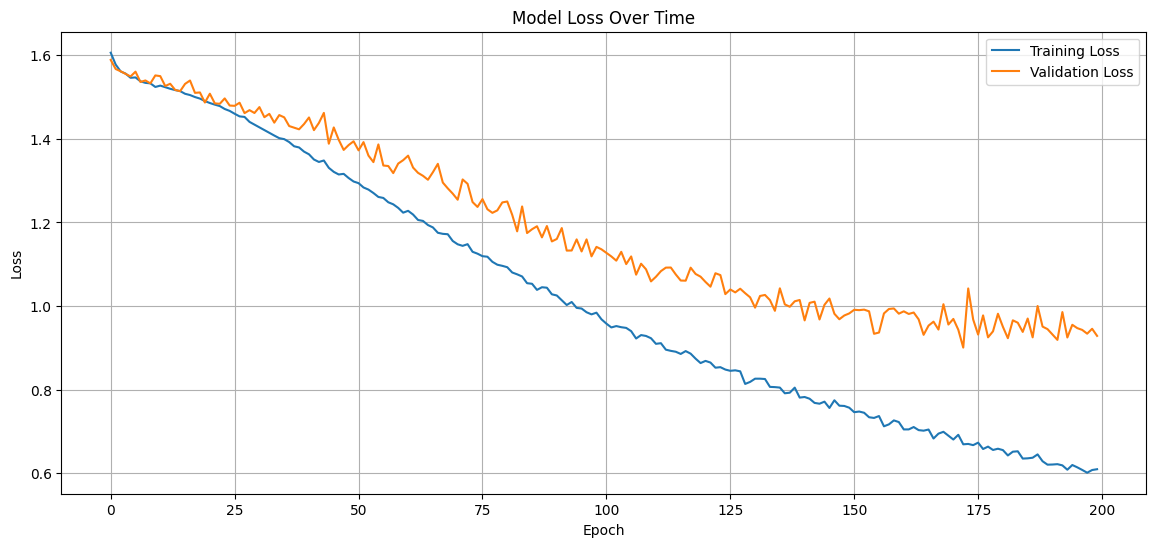

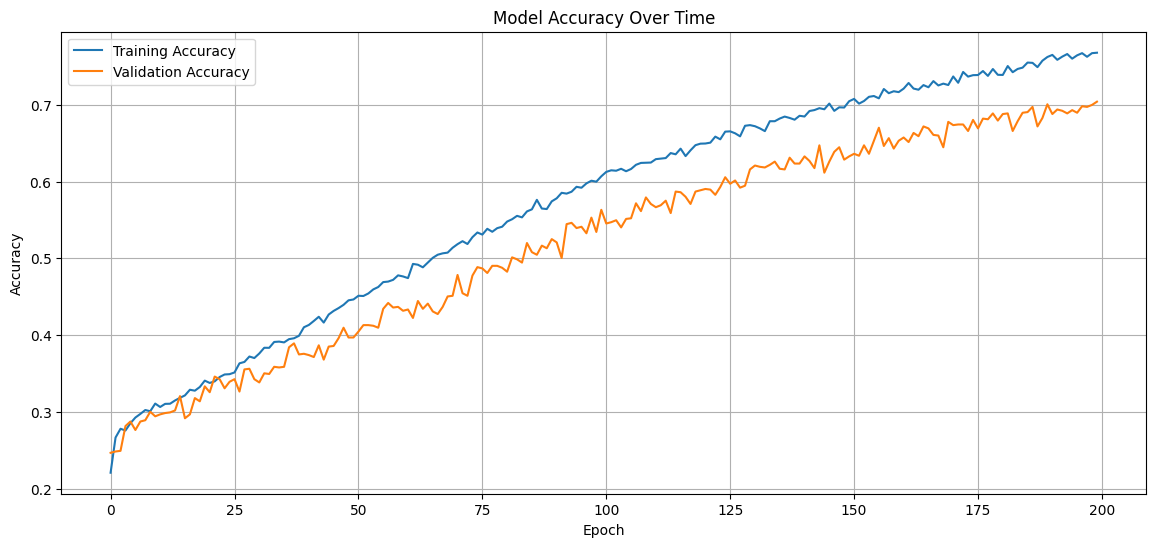


Evaluating RNN...
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
                   precision    recall  f1-score   support

    agreeableness       0.88      0.80      0.84       708
conscientiousness       0.85      0.86      0.85       713
     extraversion       0.97      0.99      0.98       726
      neuroticism       0.87      0.94      0.91       697
         openness       0.83      0.80      0.82       692

         accuracy                           0.88      3536
        macro avg       0.88      0.88      0.88      3536
     weighted avg       0.88      0.88      0.88      3536



In [127]:
# Reshape for RNN (LSTM expects 3D input: samples, timesteps, features)
X_train_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_rnn = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Train RNN Model
rnn_model = Sequential([
    LSTM(128, input_shape=(1, X_train.shape[1]), activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(64, activation='tanh'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])
rnn_model.summary()


# input_shape=(1, X_train.shape[1])
# rnn_model = tensorflow.keras.Sequential()
# rnn_model.add(LSTM(128,input_shape=input_shape))
# rnn_model.add(Dropout(0.2))
# rnn_model.add(Dense(128, activation='relu'))
# rnn_model.add(Dense(64, activation='relu'))
# rnn_model.add(Dropout(0.4))
# rnn_model.add(Dense(48, activation='relu'))
# rnn_model.add(Dropout(0.4))
# rnn_model.add(Dense(24, activation='softmax'))
# rnn_model.summary()

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the RNN model and store the history
print("Training RNN...")
history = rnn_model.fit(
    X_train_rnn, 
    y_train, 
    epochs=200, 
    batch_size=32, 
    verbose=1, 
    validation_split=0.1
)

# Save the trained model
rnn_model.save('personality_model/personality_rnn_model.h5')
print("Model saved as 'personality_rnn_model.h5'")

# Plot training history
plt.figure(figsize=(14, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot accuracy history
plt.figure(figsize=(14, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate RNN Model
print("\nEvaluating RNN...")
y_pred_rnn = np.argmax(rnn_model.predict(X_test_rnn), axis=1)
print(classification_report(y_test, y_pred_rnn, target_names=le.classes_))

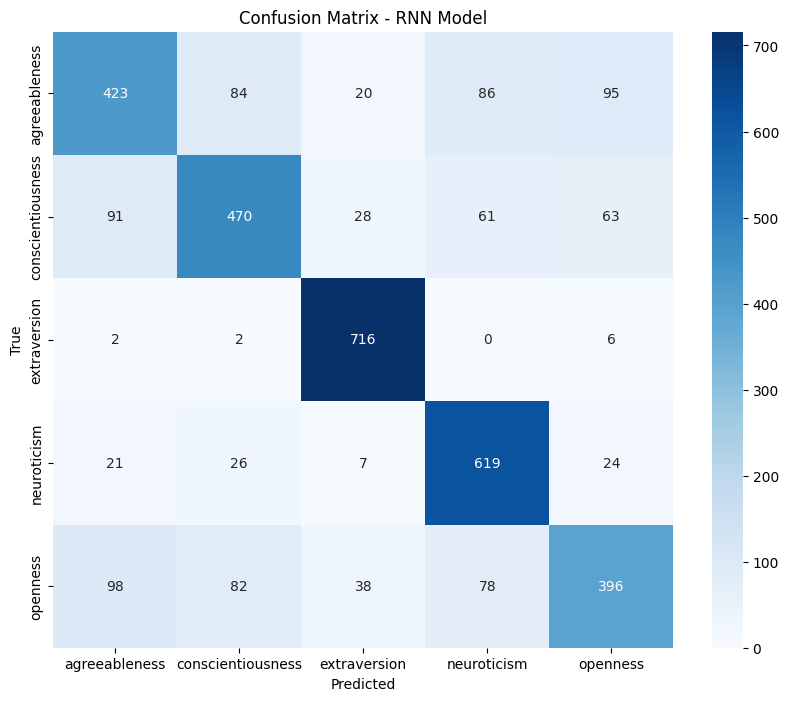


Detailed RNN Model Metrics:
Accuracy: 0.7421
Precision (weighted): 0.7351
Recall (weighted): 0.7421
F1 Score (weighted): 0.7351
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


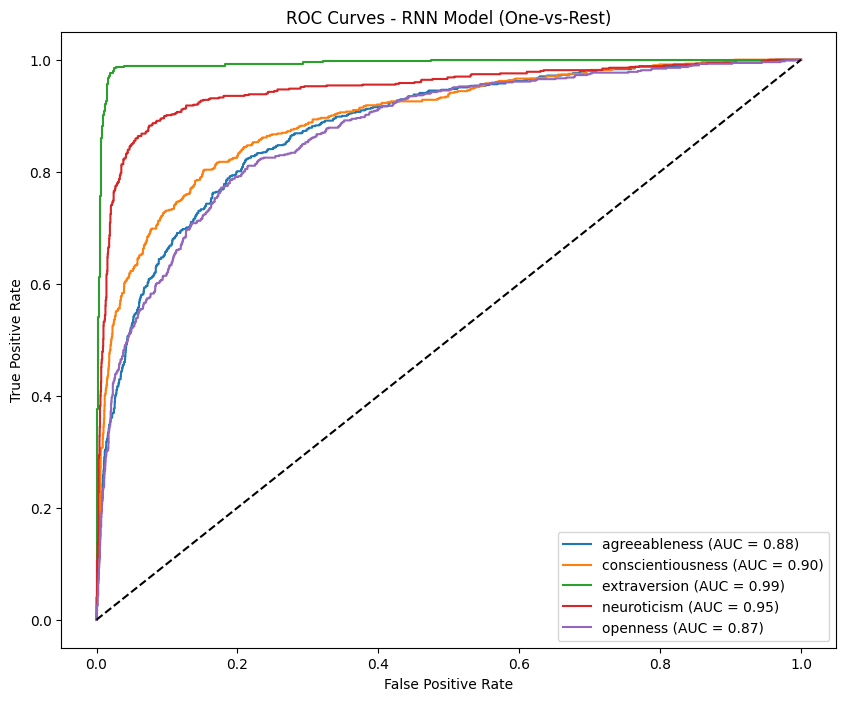

In [40]:
# Plot confusion matrix for RNN
plt.figure(figsize=(10, 8))
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred_rnn))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - RNN Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Calculate and print additional metrics
print("\nDetailed RNN Model Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rnn):.4f}")
print(f"Precision (weighted): {precision_score(y_test, y_pred_rnn, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, y_pred_rnn, average='weighted'):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, y_pred_rnn, average='weighted'):.4f}")

# Plot ROC curves for each class (one-vs-rest)
plt.figure(figsize=(10, 8))
y_pred_proba = rnn_model.predict(X_test_rnn)

for i in range(len(le.classes_)):
    y_test_binary = (y_test == i).astype(int)
    y_pred_proba_class = y_pred_proba[:, i]
    fpr, tpr, _ = roc_curve(y_test_binary, y_pred_proba_class)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{le.classes_[i]} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - RNN Model (One-vs-Rest)')
plt.legend()
plt.show()


KFold

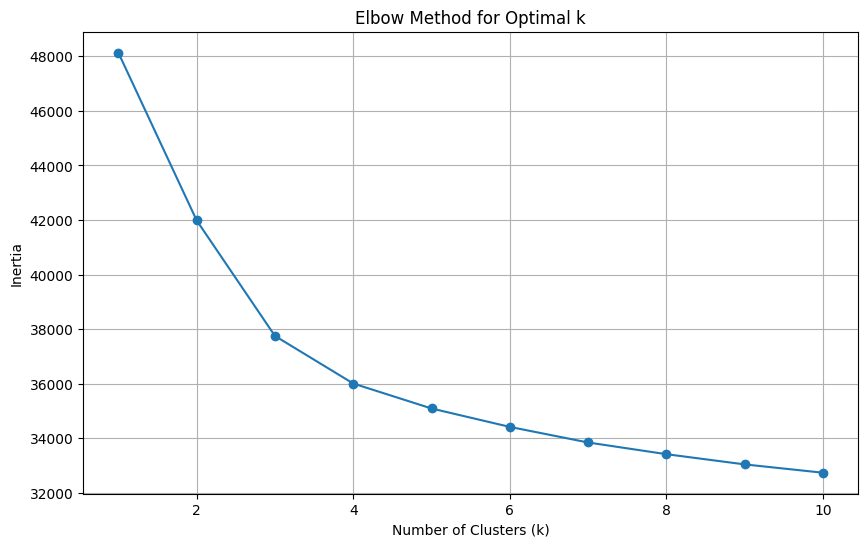

In [43]:
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

# Define the range of k values to try
k_values = range(1, 11)

# List to store the inertia values for each k
inertia_values = []

# Compute k-means clustering for each k and store the inertia
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)  # Use the scaled features
    inertia_values.append(kmeans.inertia_)

# Plot the inertia values against the number of clusters
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [47]:
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Initialize KFold
k = 3 
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize lists to store metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Perform k-fold cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_scaled), 1):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]

    # Reshape for RNN (LSTM expects 3D input: samples, timesteps, features)
    X_train_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
    X_val_rnn = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])

    # RNN model
    rnn_model = Sequential([
        LSTM(128, input_shape=(1, X_train.shape[1]), activation='tanh', return_sequences=True),
        Dropout(0.2),
        LSTM(64, activation='tanh'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(len(np.unique(y_encoded)), activation='softmax')
    ])
    rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    history = rnn_model.fit(X_train_rnn, y_train, epochs=200, batch_size=32, verbose=1, validation_data=(X_val_rnn, y_val))

    # Evaluate the model
    y_pred_val = np.argmax(rnn_model.predict(X_val_rnn), axis=1)
    accuracy_scores.append(accuracy_score(y_val, y_pred_val))
    precision_scores.append(precision_score(y_val, y_pred_val, average='weighted'))
    recall_scores.append(recall_score(y_val, y_pred_val, average='weighted'))
    f1_scores.append(f1_score(y_val, y_pred_val, average='weighted'))

    print(f"\nFold {fold} Classification Report:")
    print(classification_report(y_val, y_pred_val, target_names=le.classes_))

# Print the average metrics
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1 Score: {np.mean(f1_scores):.4f}")


Epoch 1/200
369/369 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2120 - loss: 1.6089 - val_accuracy: 0.2591 - val_loss: 1.5811
Epoch 2/200
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2743 - loss: 1.5782 - val_accuracy: 0.2862 - val_loss: 1.5657
Epoch 3/200
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2720 - loss: 1.5650 - val_accuracy: 0.2793 - val_loss: 1.5568
Epoch 4/200
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2828 - loss: 1.5566 - val_accuracy: 0.2771 - val_loss: 1.5643
Epoch 5/200
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2945 - loss: 1.5476 - val_accuracy: 0.2840 - val_loss: 1.5527
Epoch 6/200
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3029 - loss: 1.5403 - val_accuracy: 0.2771 - val_loss: 1.5504
Epoch 7/200
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2878 - loss: 1.5500 - val_accuracy: 0.2862 - val_loss: 1.5553
Epoch 8/200
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2964 - loss: 1.5435 - val_accu

### XGBoost


Training XGBoost model...


  warnings.warn(



[0]	validation_0-mlogloss:1.60566	validation_1-mlogloss:1.60549
[1]	validation_0-mlogloss:1.60196	validation_1-mlogloss:1.60164
[2]	validation_0-mlogloss:1.59828	validation_1-mlogloss:1.59781
[3]	validation_0-mlogloss:1.59461	validation_1-mlogloss:1.59405
[4]	validation_0-mlogloss:1.59104	validation_1-mlogloss:1.59038
[5]	validation_0-mlogloss:1.58742	validation_1-mlogloss:1.58666
[6]	validation_0-mlogloss:1.58396	validation_1-mlogloss:1.58308
[7]	validation_0-mlogloss:1.58054	validation_1-mlogloss:1.57962
[8]	validation_0-mlogloss:1.57714	validation_1-mlogloss:1.57607
[9]	validation_0-mlogloss:1.57367	validation_1-mlogloss:1.57253
[10]	validation_0-mlogloss:1.57040	validation_1-mlogloss:1.56916
[11]	validation_0-mlogloss:1.56698	validation_1-mlogloss:1.56568
[12]	validation_0-mlogloss:1.56373	validation_1-mlogloss:1.56234
[13]	validation_0-mlogloss:1.56045	validation_1-mlogloss:1.55901
[14]	validation_0-mlogloss:1.55721	validation_1-mlogloss:1.55572
[15]	validation_0-mlogloss:1.55405	

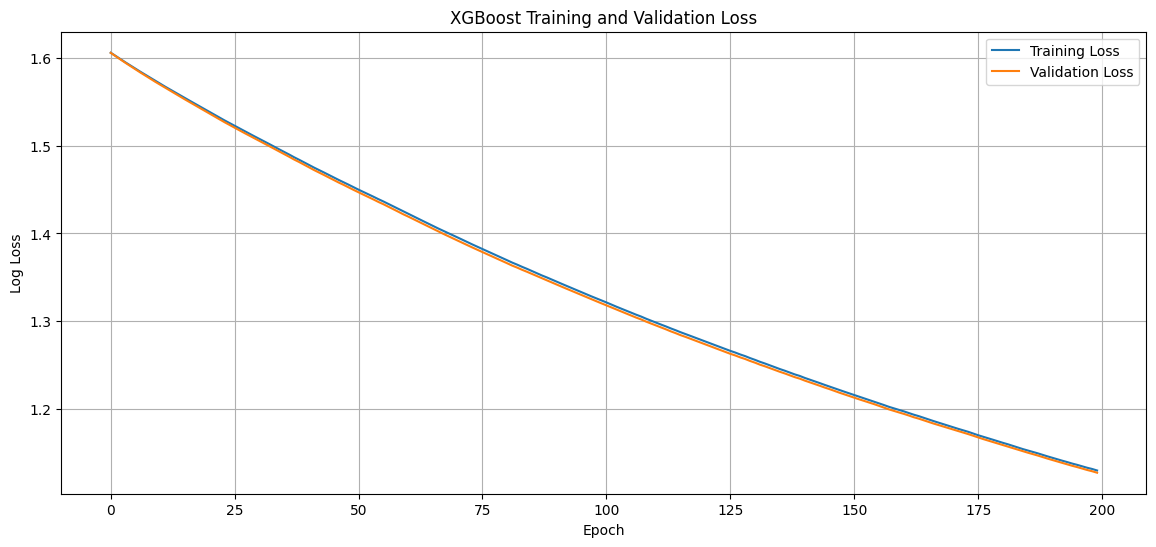


Evaluating XGBoost on Testing Data...
                   precision    recall  f1-score   support

    agreeableness       0.79      0.77      0.78       708
conscientiousness       0.80      0.77      0.78       713
     extraversion       0.78      0.95      0.86       726
      neuroticism       0.87      0.85      0.86       697
         openness       0.84      0.72      0.78       692

         accuracy                           0.81      3536
        macro avg       0.82      0.81      0.81      3536
     weighted avg       0.82      0.81      0.81      3536


XGBoost Test Metrics:
Accuracy: 0.8133
Precision (weighted): 0.8153
Recall (weighted): 0.8133
F1 Score (weighted): 0.8117

Model saved as 'personality_xgboost_model.joblib'


In [128]:
# Train XGBoost model
print("\nTraining XGBoost model...")
xgb_model = xgb.XGBClassifier(
    reg_lambda=5,  # L2 regularization
    reg_alpha=2,   # L1 regularization
    max_depth=6, 
    n_estimators=200,
    learning_rate=0.01,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)


xgb_model.fit(
    X_train, 
    y_train, 
    early_stopping_rounds=10, 
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    verbose=True
)
# Plot training and validation loss
results = xgb_model.evals_result()
plt.figure(figsize=(14, 6))
plt.plot(results['validation_0']['mlogloss'], label='Training Loss')
plt.plot(results['validation_1']['mlogloss'], label='Validation Loss')
plt.title('XGBoost Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()



# Evaluate on test set
print("\nEvaluating XGBoost on Testing Data...")
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average='weighted')
recall = recall_score(y_test, y_pred_xgb, average='weighted')
f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"\nXGBoost Test Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}") 
print(f"F1 Score (weighted): {f1:.4f}")



# Save the model
import joblib
joblib.dump(xgb_model, 'personality_model/personality_xgboost_model.joblib')
print("\nModel saved as 'personality_xgboost_model.joblib'")

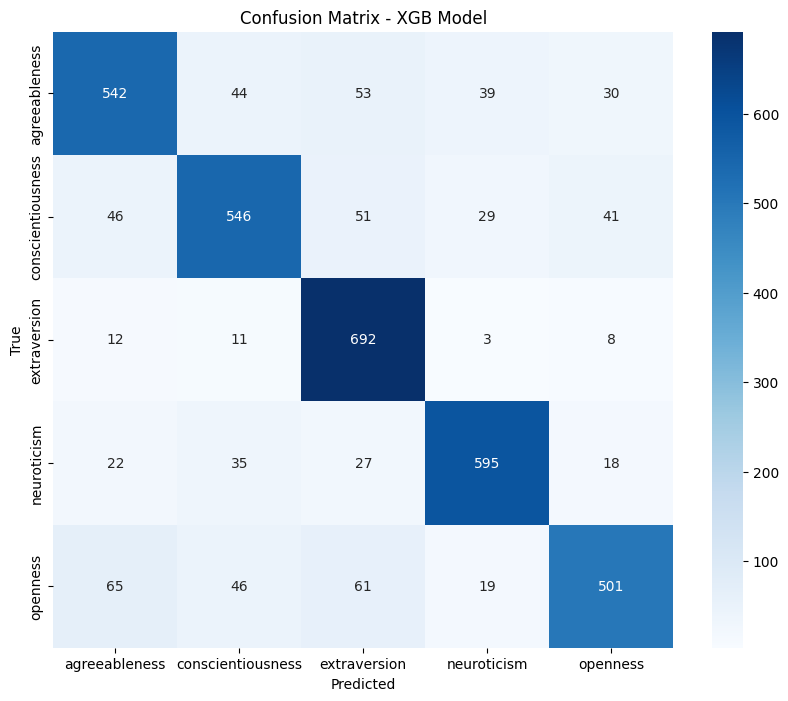

In [124]:
# Plot confusion matrix for RNN
plt.figure(figsize=(10, 8))
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred_xgb))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - XGB Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [123]:
# Initialize KFold
k = 3 
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize lists to store metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Perform k-fold cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_scaled), 1):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]

    # XGBoost model
    xgb_model = xgb.XGBClassifier(
        reg_lambda=5,  # L2 regularization
        reg_alpha=2,   # L1 regularization
        max_depth=6, 
        min_child_weight=5,
        n_estimators=200,
        learning_rate=0.01,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    )
    xgb_model.fit(X_train, y_train, early_stopping_rounds=10, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=True)

    # Evaluate the model
    y_pred_val = xgb_model.predict(X_val)
    accuracy_scores.append(accuracy_score(y_val, y_pred_val))
    precision_scores.append(precision_score(y_val, y_pred_val, average='weighted'))
    recall_scores.append(recall_score(y_val, y_pred_val, average='weighted'))
    f1_scores.append(f1_score(y_val, y_pred_val, average='weighted'))

    print(f"\nFold {fold} Classification Report:")
    print(classification_report(y_val, y_pred_val, target_names=le.classes_))

# Print the average metrics
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1 Score: {np.mean(f1_scores):.4f}")


[0]	validation_0-mlogloss:1.60580	validation_1-mlogloss:1.60686
[1]	validation_0-mlogloss:1.60220	validation_1-mlogloss:1.60429
[2]	validation_0-mlogloss:1.59865	validation_1-mlogloss:1.60173
[3]	validation_0-mlogloss:1.59512	validation_1-mlogloss:1.59920
[4]	validation_0-mlogloss:1.59155	validation_1-mlogloss:1.59661
[5]	validation_0-mlogloss:1.58804	validation_1-mlogloss:1.59413
[6]	validation_0-mlogloss:1.58454	validation_1-mlogloss:1.59164
[7]	validation_0-mlogloss:1.58116	validation_1-mlogloss:1.58920
[8]	validation_0-mlogloss:1.57779	validation_1-mlogloss:1.58676
[9]	validation_0-mlogloss:1.57444	validation_1-mlogloss:1.58436
[10]	validation_0-mlogloss:1.57099	validation_1-mlogloss:1.58189
[11]	validation_0-mlogloss:1.56764	validation_1-mlogloss:1.57942
[12]	validation_0-mlogloss:1.56421	validation_1-mlogloss:1.57698
[13]	validation_0-mlogloss:1.56095	validation_1-mlogloss:1.57456
[14]	validation_0-mlogloss:1.55765	validation_1-mlogloss:1.57218
[15]	validation_0-mlogloss:1.55453	

### Random Forest


Training Random Forest model...


  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(

  warn(



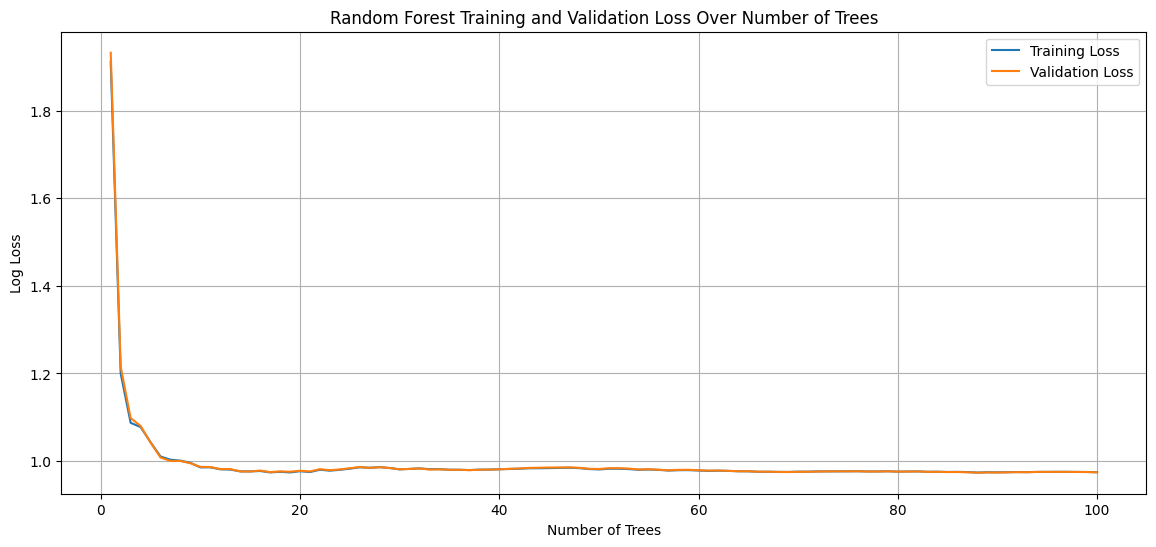


Evaluating Random Forest on Testing Data...
                   precision    recall  f1-score   support

    agreeableness       0.89      0.90      0.90       708
conscientiousness       0.92      0.93      0.93       713
     extraversion       0.95      0.98      0.96       726
      neuroticism       0.96      0.94      0.95       697
         openness       0.93      0.90      0.91       692

         accuracy                           0.93      3536
        macro avg       0.93      0.93      0.93      3536
     weighted avg       0.93      0.93      0.93      3536


Random Forest Test Metrics:
Accuracy: 0.9310
Precision (weighted): 0.9311
Recall (weighted): 0.9310
F1 Score (weighted): 0.9309

Model saved as 'personality_rf_model.joblib'


In [129]:
from sklearn.metrics import log_loss

# Train Random Forest Model
print("\nTraining Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,        # Fewer trees
    max_depth=10,            # Restrict depth
    min_samples_split=10,    # Require more samples to split
    min_samples_leaf=5,      # Require more samples in leaf nodes
    max_features='sqrt',     # Consider sqrt(number of features) at each split
    oob_score=True,          # Enable out-of-bag estimates
    random_state=42,
)
# Arrays to store the training and validation loss
train_losses = []
val_losses = []

# Train the model incrementally
n_estimators = 100  # Number of trees
for i in range(1, n_estimators + 1):
    rf_model.set_params(n_estimators=i)
    rf_model.fit(X_train, y_train)
    
    # Predict probabilities for training and validation sets
    y_train_pred_proba = rf_model.predict_proba(X_train)
    y_val_pred_proba = rf_model.predict_proba(X_test)
    
    # Calculate log loss for training and validation sets
    train_loss = log_loss(y_train, y_train_pred_proba)
    val_loss = log_loss(y_test, y_val_pred_proba)
    
    # Store the losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plot training and validation loss
plt.figure(figsize=(14, 6))
plt.plot(range(1, n_estimators + 1), train_losses, label='Training Loss')
plt.plot(range(1, n_estimators + 1), val_losses, label='Validation Loss')
plt.title('Random Forest Training and Validation Loss Over Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()


# Evaluate on test set
print("\nEvaluating Random Forest on Testing Data...")
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\nRandom Forest Test Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}") 
print(f"F1 Score (weighted): {f1:.4f}")

# Save the model
joblib.dump(rf_model, 'personality_model/personality_rf_model.joblib')
print("\nModel saved as 'personality_rf_model.joblib'")



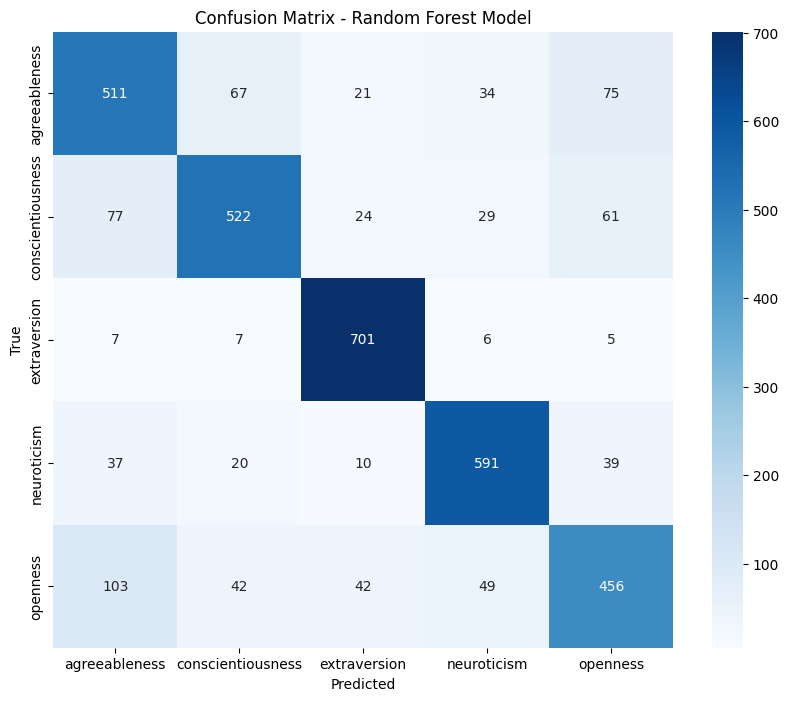

In [67]:
# Plot confusion matrix for Random Forest
plt.figure(figsize=(10, 8))
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred_rf))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [87]:
# Initialize KFold
k = 3 
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize lists to store metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Perform k-fold cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_scaled), 1):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]

    # Random Forest model
    rf_model = RandomForestClassifier(
        n_estimators=100,        # Number of trees
        max_depth=10,            # Maximum depth of the tree
        min_samples_split=10,    # Minimum number of samples required to split an internal node
        min_samples_leaf=5,      # Minimum number of samples required to be at a leaf node
        max_features='sqrt',     # Number of features to consider when looking for the best split
        oob_score=True,          # Use out-of-bag samples to estimate the generalization accuracy
        random_state=42,
    )
    rf_model.fit(X_train, y_train)

    # Evaluate the model
    y_pred_val = rf_model.predict(X_val)
    accuracy_scores.append(accuracy_score(y_val, y_pred_val))
    precision_scores.append(precision_score(y_val, y_pred_val, average='weighted'))
    recall_scores.append(recall_score(y_val, y_pred_val, average='weighted'))
    f1_scores.append(f1_score(y_val, y_pred_val, average='weighted'))

    print(f"\nFold {fold} Classification Report:")
    print(classification_report(y_val, y_pred_val, target_names=le.classes_))

# Print the average metrics
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1 Score: {np.mean(f1_scores):.4f}")



Fold 1 Classification Report:
                   precision    recall  f1-score   support

    agreeableness       0.67      0.66      0.66      1195
conscientiousness       0.74      0.69      0.71      1165
     extraversion       0.85      0.96      0.90      1195
      neuroticism       0.83      0.82      0.83      1179
         openness       0.67      0.64      0.66      1160

         accuracy                           0.76      5894
        macro avg       0.75      0.76      0.75      5894
     weighted avg       0.75      0.76      0.75      5894


Fold 2 Classification Report:
                   precision    recall  f1-score   support

    agreeableness       0.70      0.72      0.71      1171
conscientiousness       0.78      0.72      0.75      1214
     extraversion       0.83      0.96      0.89      1148
      neuroticism       0.80      0.84      0.82      1158
         openness       0.70      0.59      0.64      1202

         accuracy                           0.76

### SVM


Training SVM model...


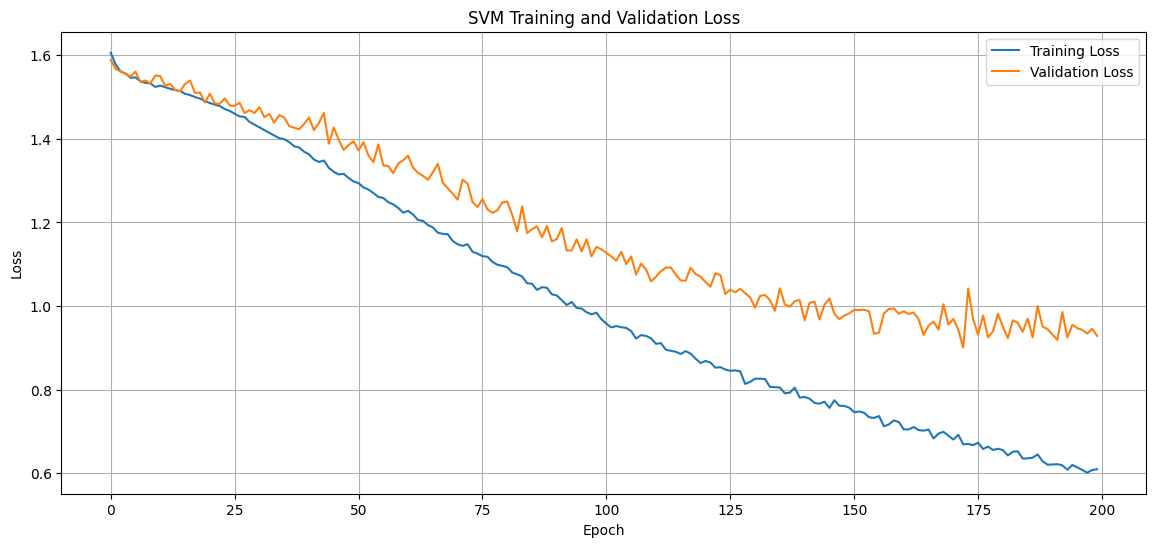


Evaluating XGBoost...
                   precision    recall  f1-score   support

    agreeableness       0.59      0.57      0.58       708
conscientiousness       0.62      0.66      0.64       713
     extraversion       0.82      0.87      0.84       726
      neuroticism       0.69      0.72      0.71       697
         openness       0.64      0.53      0.58       692

         accuracy                           0.67      3536
        macro avg       0.67      0.67      0.67      3536
     weighted avg       0.67      0.67      0.67      3536


SVM Test Metrics:
Accuracy: 0.6748
Precision (weighted): 0.6717
Recall (weighted): 0.6748
F1 Score (weighted): 0.6719

Model saved as 'personality_svm_model.joblib'


In [132]:
# Train SVM model
print("\nTraining SVM model...")
svm_model = SVC(
    C=10,           # Increase regularization
    kernel='rbf',   # Use RBF kernel for non-linear relationships
    gamma='scale',  # Start with 'scale' or fine-tune
    random_state=42,
    probability=True
)
svm_model.fit(X_train, y_train)

# Plot training and validation loss
plt.figure(figsize=(14, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('SVM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



# Evaluate on test set
print("\nEvaluating XGBoost...")
y_pred_svm = svm_model.predict(X_test)
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))
accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm, average='weighted')
recall = recall_score(y_test, y_pred_svm, average='weighted')
f1 = f1_score(y_test, y_pred_svm, average='weighted')

print(f"\nSVM Test Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}") 
print(f"F1 Score (weighted): {f1:.4f}")


# Save the model
joblib.dump(svm_model, 'personality_model/personality_svm_model.joblib')
print("\nModel saved as 'personality_svm_model.joblib'")


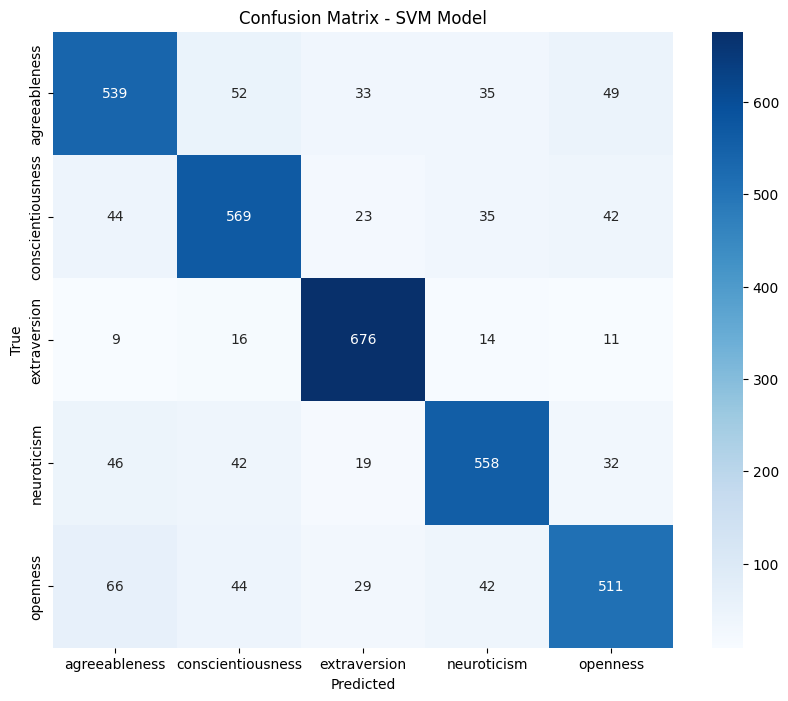

In [126]:
# Plot confusion matrix for SVM
plt.figure(figsize=(10, 8))
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_pred_svm))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - SVM Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [88]:
# Initialize KFold
k = 3 
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize lists to store metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Perform k-fold cross-validation
for fold, (train_index, val_index) in enumerate(kf.split(X_scaled), 1):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]

    svm_model = SVC(
        C=10,           # Increase regularization
        kernel='rbf',   # Use RBF kernel for non-linear relationships
        gamma='scale',  # Start with 'scale' or fine-tune
        random_state=42
    )
    svm_model.fit(X_train, y_train)

    # Evaluate the model
    y_pred_val = svm_model.predict(X_val)
    accuracy_scores.append(accuracy_score(y_val, y_pred_val))
    precision_scores.append(precision_score(y_val, y_pred_val, average='weighted'))
    recall_scores.append(recall_score(y_val, y_pred_val, average='weighted'))
    f1_scores.append(f1_score(y_val, y_pred_val, average='weighted'))

    print(f"\nFold {fold} Classification Report:")
    print(classification_report(y_val, y_pred_val, target_names=le.classes_))

# Print the average metrics
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1 Score: {np.mean(f1_scores):.4f}")


Fold 1 Classification Report:
                   precision    recall  f1-score   support

    agreeableness       0.56      0.52      0.54      1195
conscientiousness       0.58      0.62      0.60      1165
     extraversion       0.78      0.85      0.81      1195
      neuroticism       0.66      0.69      0.67      1179
         openness       0.55      0.48      0.52      1160

         accuracy                           0.63      5894
        macro avg       0.63      0.63      0.63      5894
     weighted avg       0.63      0.63      0.63      5894


Fold 2 Classification Report:
                   precision    recall  f1-score   support

    agreeableness       0.55      0.58      0.56      1171
conscientiousness       0.61      0.60      0.60      1214
     extraversion       0.76      0.88      0.81      1148
      neuroticism       0.66      0.70      0.68      1158
         openness       0.59      0.45      0.51      1202

         accuracy                           0.64

### Ensemble

In [18]:
# Load the trained models
rnn_model = tf.keras.models.load_model('personality_model/personality_rnn_model.h5')
xgb_model = joblib.load('personality_model/personality_xgboost_model.joblib')
rf_model = joblib.load('personality_model/personality_rf_model.joblib')
svm_model = joblib.load('personality_model/personality_svm_model.joblib')

# # Predict emotion traits using the models
# rnn_prediction = rnn_model.predict(features_rnn)
# xgb_prediction = xgb_model.predict_proba(features)
# rf_prediction = rf_model.predict_proba(features)
# svm_prediction = svm_model.predict_proba(features)

# # Soft Voting (Average) Ensemble
# final_probs = (rnn_prediction + xgb_prediction + rf_prediction + svm_prediction) / 4

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[0 4 3 ... 2 2 3]
[4 4 3 ... 2 2 3]
Ensemble Model Classification Report:
                   precision    recall  f1-score   support

    agreeableness       0.87      0.83      0.85       708
conscientiousness       0.86      0.87      0.86       713
     extraversion       0.96      0.99      0.97       726
      neuroticism       0.90      0.93      0.91       697
         openness       0.85      0.82      0.83       692

         accuracy                           0.89      3536
        macro avg       0.89      0.89      0.89      3536
     weighted avg       0.89      0.89      0.89      3536



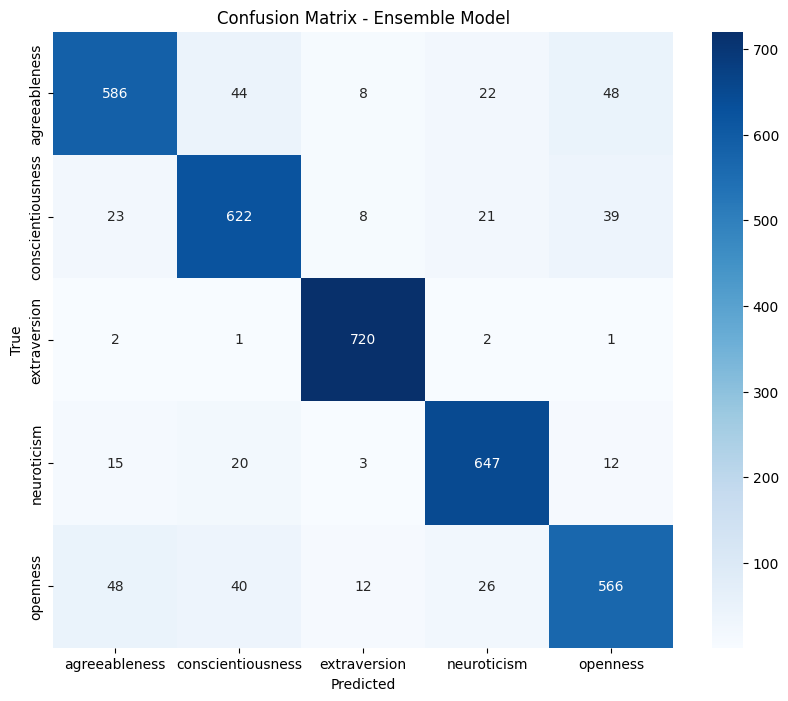


Detailed Ensemble Model Metrics:
Accuracy: 0.8883
Precision (weighted): 0.8874
Recall (weighted): 0.8883
F1 Score (weighted): 0.8876


In [19]:
X_test_rnn = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])
# Predict probabilities for each model
rnn_pred_proba = rnn_model.predict(X_test_rnn)
xgb_pred_proba = xgb_model.predict_proba(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)
svm_pred_proba = svm_model.predict_proba(X_test)

# Average the probabilities (soft voting)
ensemble_pred_proba = (rnn_pred_proba + xgb_pred_proba + rf_pred_proba + svm_pred_proba) / 4

# Get the final predictions by taking the class with the highest average probability
ensemble_pred = np.argmax(ensemble_pred_proba, axis=1)
print(ensemble_pred)
print(y_test)

# Evaluate the ensemble model
print("Ensemble Model Classification Report:")
print(classification_report(y_test, ensemble_pred, target_names=le.classes_))

# Plot confusion matrix for Ensemble Model
plt.figure(figsize=(10, 8))
cm = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(ensemble_pred))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Ensemble Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Calculate and print additional metrics
print("\nDetailed Ensemble Model Metrics:")
print(f"Accuracy: {accuracy_score(y_test, ensemble_pred):.4f}")
print(f"Precision (weighted): {precision_score(y_test, ensemble_pred, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test, ensemble_pred, average='weighted'):.4f}")
print(f"F1 Score (weighted): {f1_score(y_test, ensemble_pred, average='weighted'):.4f}")


In [20]:
# Calculate accuracy for each model
accuracy_rnn = accuracy_score(y_test, np.argmax(rnn_pred_proba, axis=1))
accuracy_xgb = accuracy_score(y_test, np.argmax(xgb_pred_proba, axis=1))
accuracy_rf = accuracy_score(y_test, np.argmax(rf_pred_proba, axis=1))
accuracy_svm = accuracy_score(y_test, np.argmax(svm_pred_proba, axis=1))
accuracy_ensemble = accuracy_score(y_test, ensemble_pred)

# Print the accuracy of each model
print(f"RNN Model Accuracy: {accuracy_rnn:.4f}")
print(f"XGBoost Model Accuracy: {accuracy_xgb:.4f}")
print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")
print(f"SVM Model Accuracy: {accuracy_svm:.4f}")
print(f"Ensemble Model Accuracy: {accuracy_ensemble:.4f}")

RNN Model Accuracy: 0.8807
XGBoost Model Accuracy: 0.8133
Random Forest Model Accuracy: 0.9310
SVM Model Accuracy: 0.6731
Ensemble Model Accuracy: 0.8883
